# Exotic Options Pricing: Asian and Barrier Options

Path-dependent derivatives priced via Monte Carlo. No closed-form solutions exist for these instruments.

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import matplotlib.pyplot as plt
from black_scholes import black_scholes_call
from exotics import asian_call_fixed_strike, up_and_out_call


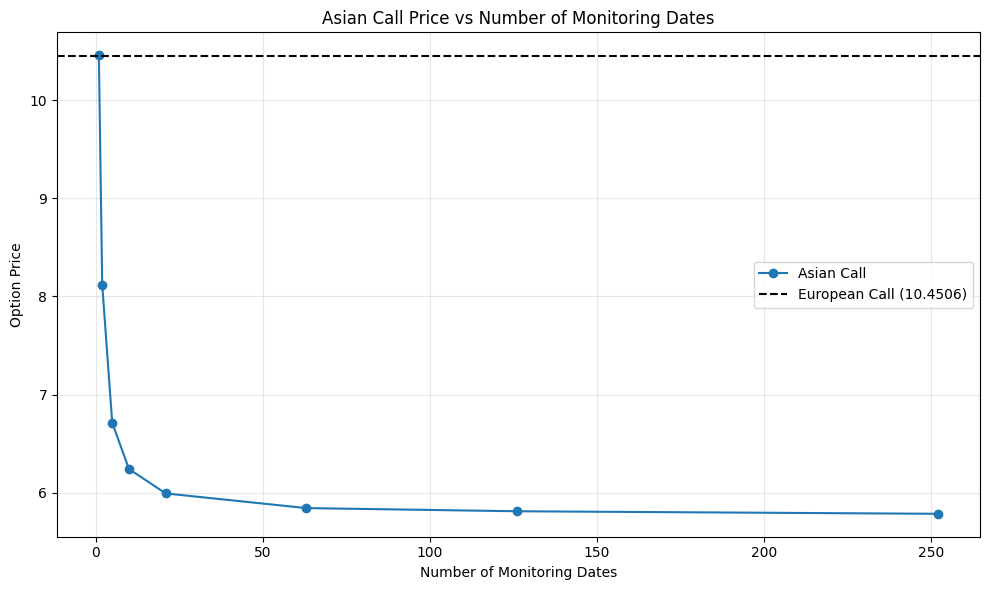

In [2]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
bs = black_scholes_call(S0, K, r, sigma, T)

steps = [1, 2, 5, 10, 21, 63, 126, 252]
asian_prices = []
asian_ses = []

for n in steps:
    result = asian_call_fixed_strike(S0, K, r, sigma, T, n_steps=n)
    asian_prices.append(result['price'])
    asian_ses.append(result['stderr'])

plt.figure(figsize=(10, 6))
plt.plot(steps, asian_prices, 'o-', label='Asian Call')
plt.axhline(y=bs, color='black', linestyle='--', label=f'European Call ({bs:.4f})')
plt.xlabel('Number of Monitoring Dates')
plt.ylabel('Option Price')
plt.title('Asian Call Price vs Number of Monitoring Dates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/asian_vs_steps.png', dpi=300)
plt.show()

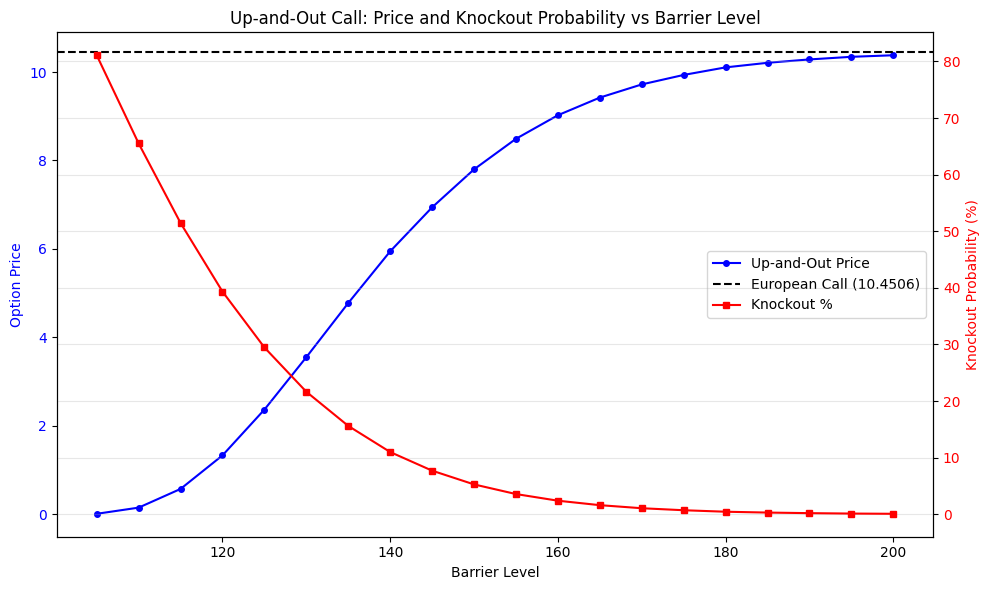

In [3]:
barriers = np.arange(105, 205, 5)
uo_prices = []
uo_ko = []

for B in barriers:
    result = up_and_out_call(S0, K, float(B), r, sigma, T)
    uo_prices.append(result['price'])
    uo_ko.append(result['knockout_pct'])

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(barriers, uo_prices, 'b-o', markersize=4, label='Up-and-Out Price')
ax1.axhline(y=bs, color='black', linestyle='--', label=f'European Call ({bs:.4f})')
ax1.set_xlabel('Barrier Level')
ax1.set_ylabel('Option Price', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(barriers, [k * 100 for k in uo_ko], 'r-s', markersize=4, label='Knockout %')
ax2.set_ylabel('Knockout Probability (%)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Up-and-Out Call: Price and Knockout Probability vs Barrier Level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/barrier_vs_level.png', dpi=300)
plt.show()